In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/vbookshelf/respiratory-sound-database/demographic_info.txt
/kaggle/input/datasets/vbookshelf/respiratory-sound-database/Respiratory_Sound_Database/Respiratory_Sound_Database/patient_diagnosis.csv
/kaggle/input/datasets/vbookshelf/respiratory-sound-database/Respiratory_Sound_Database/Respiratory_Sound_Database/filename_format.txt
/kaggle/input/datasets/vbookshelf/respiratory-sound-database/Respiratory_Sound_Database/Respiratory_Sound_Database/filename_differences.txt
/kaggle/input/datasets/vbookshelf/respiratory-sound-database/Respiratory_Sound_Database/Respiratory_Sound_Database/audio_and_txt_files/168_1b1_Al_sc_Meditron.txt
/kaggle/input/datasets/vbookshelf/respiratory-sound-database/Respiratory_Sound_Database/Respiratory_Sound_Database/audio_and_txt_files/162_1b2_Ar_mc_AKGC417L.wav
/kaggle/input/datasets/vbookshelf/respiratory-sound-database/Respiratory_Sound_Database/Respiratory_Sound_Database/audio_and_txt_files/172_1b4_Ar_mc_AKGC417L.txt
/kaggle/input/datase

In [ ]:
# Run this cell once to install dependencies
!pip install tensorflow librosa scikit-learn matplotlib seaborn tqdm soundfile -q

In [2]:
import os, re, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm.notebook import tqdm

import librosa
import librosa.display

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print('TensorFlow version:', tf.__version__)
print('GPU available:', tf.config.list_physical_devices('GPU'))

2026-03-03 13:49:19.775608: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772545759.791342     110 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772545759.795698     110 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772545759.808605     110 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772545759.808635     110 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772545759.808638     110 computation_placer.cc:177] computation placer alr

TensorFlow version: 2.19.0
GPU available: []


2026-03-03 13:49:26.388987: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [5]:
class Config:
    _base      = Path('/kaggle/input/datasets/vbookshelf/respiratory-sound-database')
    AUDIO_DIR  = _base / 'Respiratory_Sound_Database/Respiratory_Sound_Database/audio_and_txt_files'
    DIAG_FILE  = _base / 'Respiratory_Sound_Database/Respiratory_Sound_Database/patient_diagnosis.csv'
    DEMOG_FILE = _base / '/kaggle/input/datasets/vbookshelf/respiratory-sound-database/demographic_info.txt'
    OUTPUT_DIR = Path('/kaggle/working/outputs')
    SAMPLE_RATE   = 22050
    DURATION      = 5.0
    N_MELS        = 128
    N_FFT         = 2048
    HOP_LENGTH    = 512
    FMIN          = 50
    FMAX          = 2000
    IMG_SIZE      = (128, 128)
    BATCH_SIZE    = 32
    EPOCHS        = 60
    LEARNING_RATE = 3e-4
    TEST_SIZE     = 0.20
    VAL_SIZE      = 0.15
    SOUND_LABELS  = {(0,0):'Normal',(1,0):'Crackle',(0,1):'Wheeze',(1,1):'Both'}
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

cfg = Config()
wav_files   = sorted(cfg.AUDIO_DIR.glob('*.wav'))
annot_files = sorted(cfg.AUDIO_DIR.glob('*.txt'))
for label, path in [('AUDIO_DIR',cfg.AUDIO_DIR),('DIAG_FILE',cfg.DIAG_FILE),('DEMOG_FILE',cfg.DEMOG_FILE)]:
    print(('OK' if path.exists() else 'NOT FOUND'), label, '->', path)
print(f'WAV files : {len(wav_files)}')
print(f'TXT files : {len(annot_files)}')

OK AUDIO_DIR -> /kaggle/input/datasets/vbookshelf/respiratory-sound-database/Respiratory_Sound_Database/Respiratory_Sound_Database/audio_and_txt_files
OK DIAG_FILE -> /kaggle/input/datasets/vbookshelf/respiratory-sound-database/Respiratory_Sound_Database/Respiratory_Sound_Database/patient_diagnosis.csv
OK DEMOG_FILE -> /kaggle/input/datasets/vbookshelf/respiratory-sound-database/demographic_info.txt
WAV files : 920
TXT files : 920


In [6]:
class DataLoader:
    @staticmethod
    def parse_filename(fname):
        name  = Path(fname).stem
        parts = name.split('_')
        rec_raw = parts[1] if len(parts) > 1 else '0'
        rec_index = int(''.join(filter(str.isdigit, rec_raw)) or 0)
        return {
            'patient_id':     int(parts[0]),
            'rec_index':      rec_index,
            'chest_location': parts[2] if len(parts) > 2 else '',
            'acq_mode':       parts[3] if len(parts) > 3 else '',
            'device':         '_'.join(parts[4:]) if len(parts) > 4 else '',
            'filename':       name,
        }

    @staticmethod
    def load_annotation(annot_path):
        return pd.read_csv(annot_path, sep='\t', header=None,
                           names=['start','end','crackle','wheeze'])

    def build_master_table(self):
        print('[1/3] Loading diagnosis & demographics...')
        diag_df  = pd.read_csv(cfg.DIAG_FILE, header=None, names=['patient_id','diagnosis'])
        demog_df = pd.read_csv(cfg.DEMOG_FILE, sep='\t', header=None,
                               names=['patient_id','age','sex','adult_bmi','child_weight','child_height'])
        diag_df['patient_id']  = pd.to_numeric(diag_df['patient_id'],  errors='coerce').astype('Int64')
        demog_df['patient_id'] = pd.to_numeric(demog_df['patient_id'], errors='coerce').astype('Int64')

        print('[2/3] Parsing audio + annotations...')
        records, skipped = [], 0
        for wav_path in tqdm(wav_files, desc='Files'):
            annot_path = wav_path.with_suffix('.txt')
            if not annot_path.exists():
                skipped += 1; continue
            try:
                meta = self.parse_filename(wav_path.name)
                ann  = self.load_annotation(annot_path)
                records.append({**meta,
                    'wav_path':    str(wav_path),
                    'start':       float(ann['start'].iloc[0]),
                    'end':         float(ann['end'].iloc[-1]),
                    'crackle':     int(ann['crackle'].max()),
                    'wheeze':      int(ann['wheeze'].max()),
                    'sound_label': cfg.SOUND_LABELS[(int(ann['crackle'].max()), int(ann['wheeze'].max()))]})
            except Exception as e:
                skipped += 1

        print(f'  Parsed: {len(records)} | Skipped: {skipped}')
        master = pd.DataFrame(records)
        master['patient_id'] = master['patient_id'].astype('Int64')
        print('[3/3] Merging metadata...')
        master = master.merge(diag_df,  on='patient_id', how='left')
        master = master.merge(demog_df, on='patient_id', how='left')
        diag_map = {'Healthy':'Healthy','COPD':'COPD','URTI':'URTI','LRTI':'LRTI',
                    'Bronchiolitis':'Bronchiolitis','Pneumonia':'Pneumonia',
                    'Bronchiectasis':'Bronchiectasis','Asthma':'Asthma'}
        master['diagnosis_group'] = master['diagnosis'].map(
            lambda x: diag_map.get(str(x).strip(), 'Other'))
        print(f'Done: {len(master)} records | {master["patient_id"].nunique()} patients')
        return master

loader = DataLoader()
master = loader.build_master_table()
master.to_csv(cfg.OUTPUT_DIR / 'master_table.csv', index=False)
print('Sound labels:'); print(master['sound_label'].value_counts())
print('Diagnoses:');    print(master['diagnosis_group'].value_counts())
master.head()

[1/3] Loading diagnosis & demographics...
[2/3] Parsing audio + annotations...


Files:   0%|          | 0/920 [00:00<?, ?it/s]

  Parsed: 920 | Skipped: 0
[3/3] Merging metadata...
Done: 920 records | 126 patients
Sound labels:
sound_label
Crackle    297
Normal     287
Both       202
Wheeze     134
Name: count, dtype: int64
Diagnoses:
diagnosis_group
COPD              793
Pneumonia          37
Healthy            35
URTI               23
Bronchiectasis     16
Bronchiolitis      13
LRTI                2
Asthma              1
Name: count, dtype: int64


,patient_id,rec_index,chest_location,acq_mode,device,filename,wav_path,start,end,crackle,wheeze,sound_label,diagnosis,age,sex,adult_bmi,child_weight,child_height,diagnosis_group
0,101,11,Al,sc,Meditron,101_1b1_Al_sc_Meditron,/kaggle/input/datasets/vbookshelf/respiratory-...,0.036,19.964,0,0,Normal,URTI,NaN,NaN,NaN,NaN,NaN,URTI
1,101,11,Pr,sc,Meditron,101_1b1_Pr_sc_Meditron,/kaggle/input/datasets/vbookshelf/respiratory-...,0.036,19.936,0,0,Normal,URTI,NaN,NaN,NaN,NaN,NaN,URTI
2,102,11,Ar,sc,Meditron,102_1b1_Ar_sc_Meditron,/kaggle/input/datasets/vbookshelf/respiratory-...,0.264,19.964,0,0,Normal,Healthy,NaN,NaN,NaN,NaN,NaN,Healthy
3,103,22,Ar,mc,LittC2SE,103_2b2_Ar_mc_LittC2SE,/kaggle/input/datasets/vbookshelf/respiratory-...,0.364,19.979,0,1,Wheeze,Asthma,NaN,NaN,NaN,NaN,NaN,Asthma
4,104,11,Al,sc,Litt3200,104_1b1_Al_sc_Litt3200,/kaggle/input/datasets/vbookshelf/respiratory-...,0.000,15.856,0,0,Normal,COPD,NaN,NaN,NaN,NaN,NaN,COPD


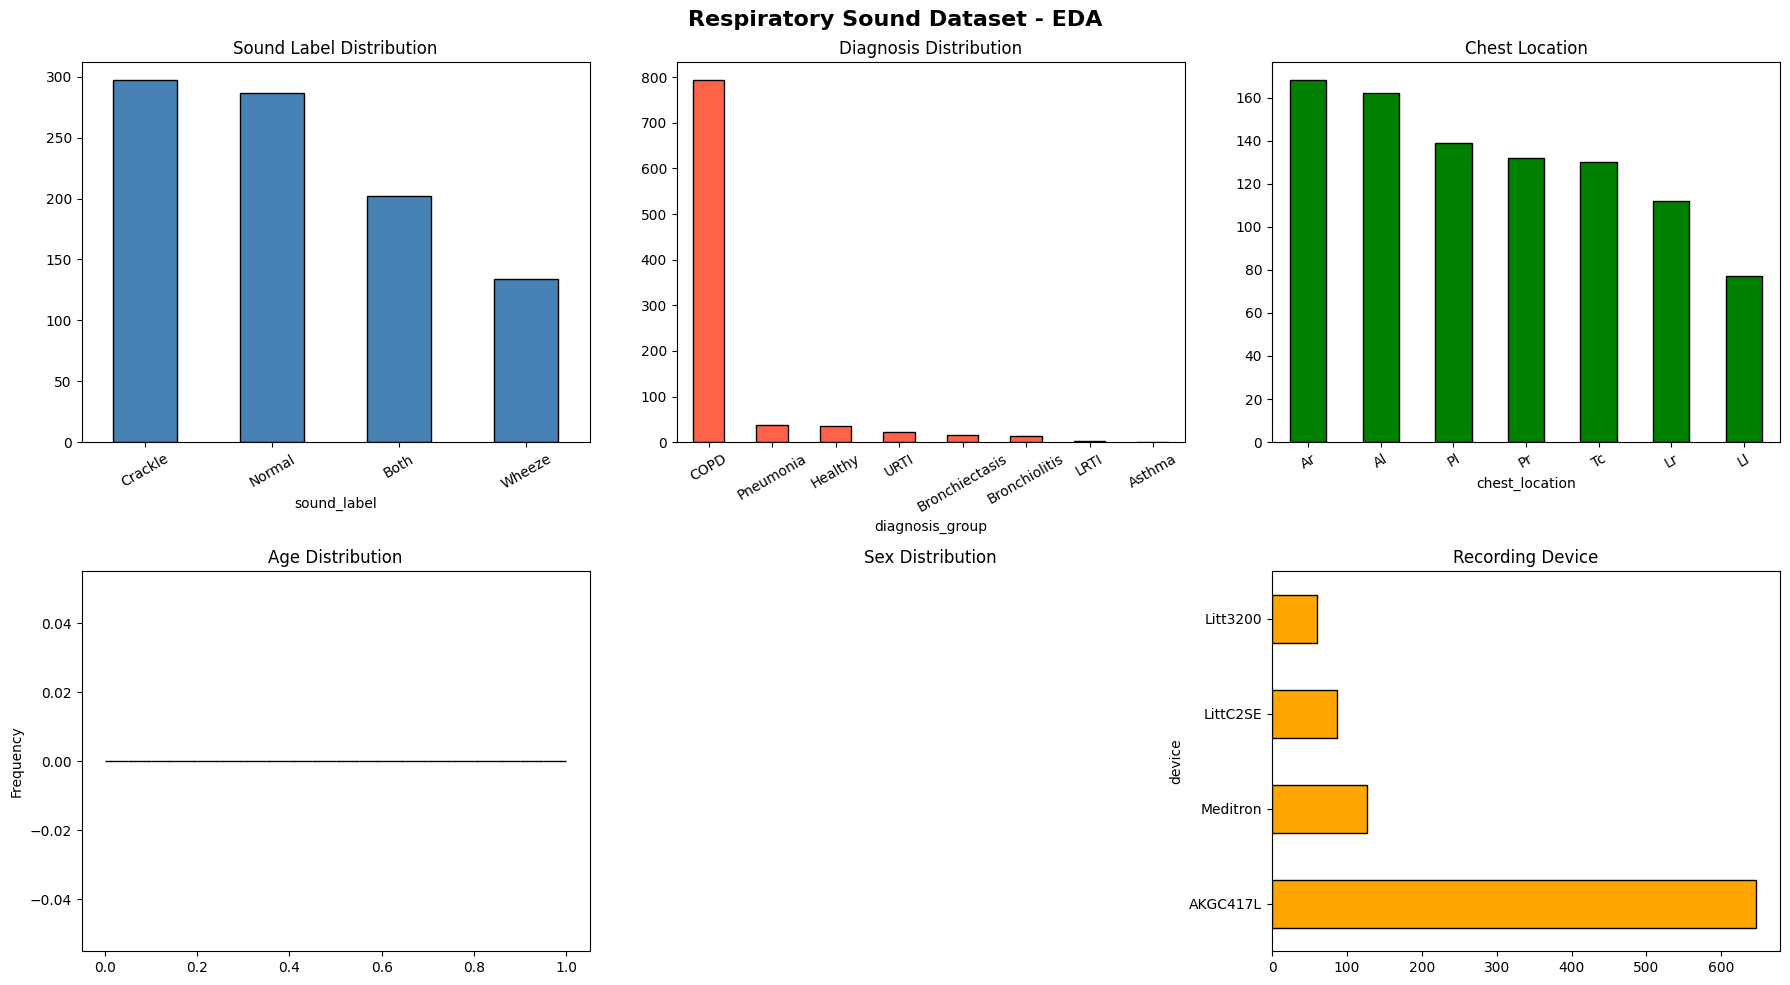

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Respiratory Sound Dataset - EDA', fontsize=16, fontweight='bold')
master['sound_label'].value_counts().plot(kind='bar', ax=axes[0,0], color='steelblue', edgecolor='black')
axes[0,0].set_title('Sound Label Distribution'); axes[0,0].tick_params(axis='x', rotation=30)
master['diagnosis_group'].value_counts().plot(kind='bar', ax=axes[0,1], color='tomato', edgecolor='black')
axes[0,1].set_title('Diagnosis Distribution'); axes[0,1].tick_params(axis='x', rotation=30)
master['chest_location'].value_counts().plot(kind='bar', ax=axes[0,2], color='green', edgecolor='black')
axes[0,2].set_title('Chest Location'); axes[0,2].tick_params(axis='x', rotation=30)
master['age'].dropna().astype(float).plot(kind='hist', bins=20, ax=axes[1,0], color='purple', edgecolor='black')
axes[1,0].set_title('Age Distribution')
master['sex'].value_counts().plot(kind='pie', ax=axes[1,1], autopct='%1.1f%%', colors=['#66b3ff','#ff9999'])
axes[1,1].set_title('Sex Distribution'); axes[1,1].set_ylabel('')
master['device'].value_counts().plot(kind='barh', ax=axes[1,2], color='orange', edgecolor='black')
axes[1,2].set_title('Recording Device')
plt.tight_layout()
plt.savefig(cfg.OUTPUT_DIR / 'eda_overview.png', dpi=150)
plt.show()

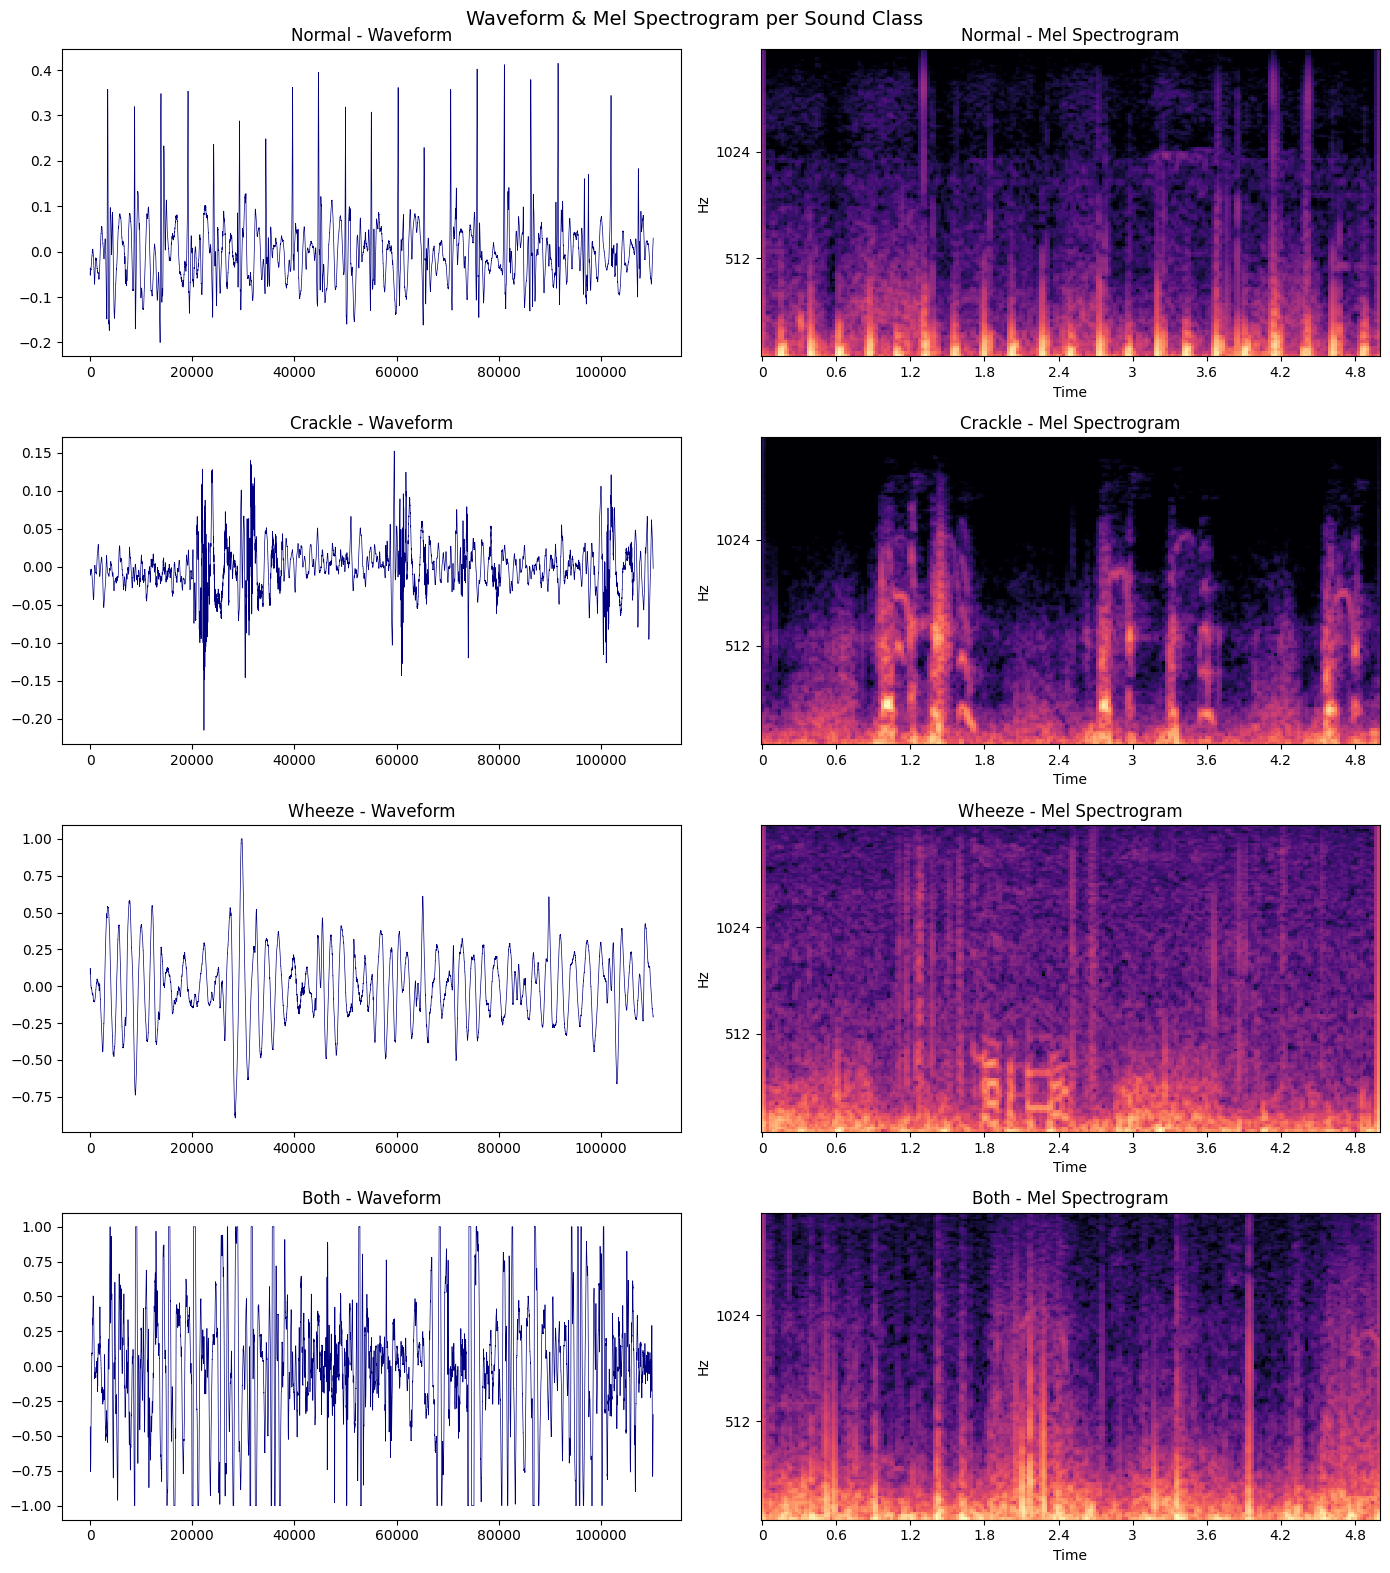

In [8]:
fig, axes = plt.subplots(4, 2, figsize=(14, 16))
fig.suptitle('Waveform & Mel Spectrogram per Sound Class', fontsize=14)
for i, label in enumerate(['Normal', 'Crackle', 'Wheeze', 'Both']):
    sub = master[master['sound_label'] == label]
    if sub.empty: continue
    row = sub.iloc[0]
    target_len = int(cfg.DURATION * cfg.SAMPLE_RATE)
    y, sr = librosa.load(row['wav_path'], sr=cfg.SAMPLE_RATE,
                         offset=row['start'], duration=row['end'] - row['start'])
    y = np.pad(y, (0, max(0, target_len - len(y))))[:target_len]
    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_fft=cfg.N_FFT,
              hop_length=cfg.HOP_LENGTH, n_mels=cfg.N_MELS, fmin=cfg.FMIN, fmax=cfg.FMAX)
    log_mel = librosa.power_to_db(mel, ref=np.max)
    axes[i,0].plot(y, color='navy', linewidth=0.5)
    axes[i,0].set_title(f'{label} - Waveform')
    librosa.display.specshow(log_mel, sr=sr, hop_length=cfg.HOP_LENGTH,
                             x_axis='time', y_axis='mel', fmin=cfg.FMIN, fmax=cfg.FMAX,
                             ax=axes[i,1], cmap='magma')
    axes[i,1].set_title(f'{label} - Mel Spectrogram')
plt.tight_layout()
plt.savefig(cfg.OUTPUT_DIR / 'audio_samples.png', dpi=150)
plt.show()

Cleaning + Extracting:   0%|          | 0/920 [00:00<?, ?it/s]

Done. Kept: 920 | Skipped: 0
Spectrograms shape: (920, 128, 128, 1)
Sound counts: {'Crackle': 297, 'Normal': 287, 'Both': 202, 'Wheeze': 134}
Diag counts: {'COPD': 793, 'Pneumonia': 37, 'Healthy': 35, 'URTI': 23, 'Bronchiectasis': 16, 'Bronchiolitis': 13, 'LRTI': 2, 'Asthma': 1}


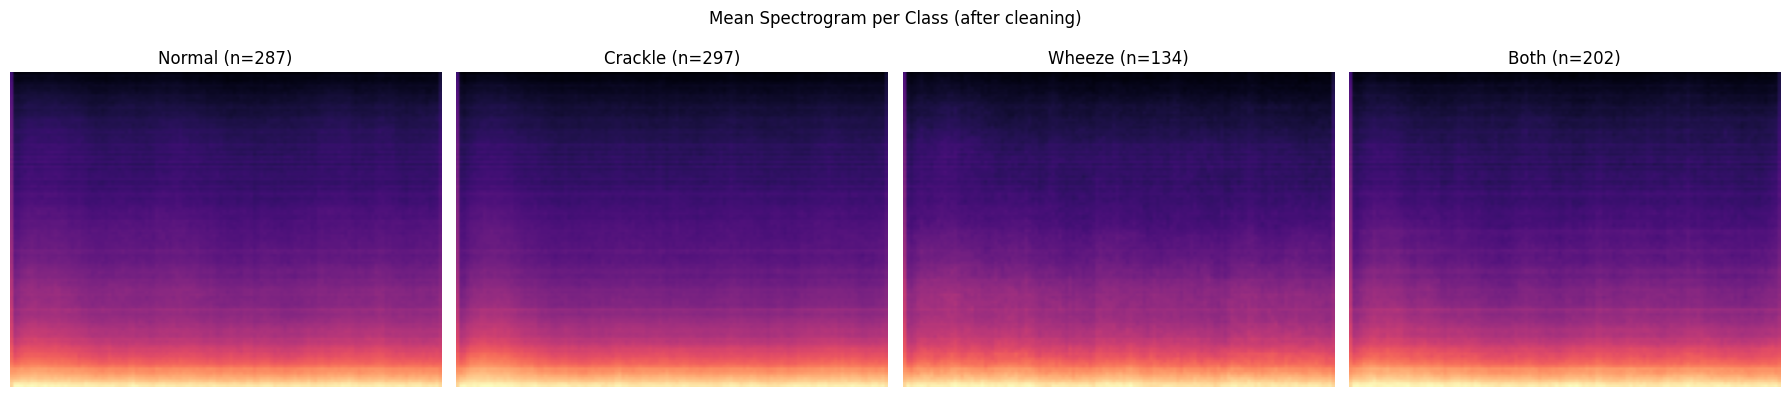

In [10]:
from scipy.signal import butter, sosfilt
def bandpass_filter(y, sr, lowcut=50, highcut=2000):
    nyq = sr / 2
    sos = butter(4, [lowcut/nyq, highcut/nyq], btype='band', output='sos')
    return sosfilt(sos, y).astype(np.float32)

def clean_segment(wav_path, start, end, sr=22050):
    target_len = int(cfg.DURATION * sr)
    y, _ = librosa.load(wav_path, sr=sr, offset=start, duration=end - start)
    if len(y) == 0 or np.mean(y**2) < 1e-6:
        return None
    y, _ = librosa.effects.trim(y, top_db=20)
    y    = bandpass_filter(y, sr)
    peak = np.max(np.abs(y))
    if peak > 0: y = y / peak
    y = np.pad(y, (0, max(0, target_len - len(y))))
    return y[:target_len]

def compute_mel(y, sr=22050):
    mel     = librosa.feature.melspectrogram(
                y=y, sr=sr, n_fft=cfg.N_FFT, hop_length=cfg.HOP_LENGTH,
                n_mels=cfg.N_MELS, fmin=cfg.FMIN, fmax=cfg.FMAX)
    log_mel = librosa.power_to_db(mel, ref=np.max)
    img     = tf.image.resize(log_mel[..., np.newaxis], cfg.IMG_SIZE).numpy()
    img     = (img - img.mean()) / (img.std() + 1e-6)
    return img.astype(np.float32)

cache_path = cfg.OUTPUT_DIR / 'features_clean.npz'
if cache_path.exists():
    print('Loading cached features...')
    d = np.load(cache_path, allow_pickle=True)
    spectrograms = d['spectrograms']
    labels_sound = d['labels_sound'].tolist()
    labels_diag  = d['labels_diag'].tolist()
else:
    specs, lsound, ldiag, skipped = [], [], [], 0
    for _, row in tqdm(master.iterrows(), total=len(master), desc='Cleaning + Extracting'):
        y = clean_segment(row['wav_path'], row['start'], row['end'])
        if y is None:
            skipped += 1; continue
        specs.append(compute_mel(y))
        lsound.append(row['sound_label'])
        ldiag.append(row['diagnosis_group'])
    spectrograms = np.array(specs, dtype=np.float32)
    labels_sound = lsound
    labels_diag  = ldiag
    np.savez_compressed(cache_path, spectrograms=spectrograms,
                        labels_sound=np.array(lsound), labels_diag=np.array(ldiag))
    print(f'Done. Kept: {len(specs)} | Skipped: {skipped}')

print('Spectrograms shape:', spectrograms.shape)
print('Sound counts:', pd.Series(labels_sound).value_counts().to_dict())
print('Diag counts:',  pd.Series(labels_diag).value_counts().to_dict())

# Mean spectrogram per class
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, label in zip(axes, ['Normal','Crackle','Wheeze','Both']):
    idx = [i for i,l in enumerate(labels_sound) if l == label]
    if idx:
        ax.imshow(spectrograms[idx].mean(axis=0)[...,0], aspect='auto', origin='lower', cmap='magma')
        ax.set_title(f'{label} (n={len(idx)})')
        ax.axis('off')
fig.suptitle('Mean Spectrogram per Class (after cleaning)')
plt.tight_layout()
plt.savefig(cfg.OUTPUT_DIR / 'mean_specs.png', dpi=150)
plt.show()

In [11]:
def balance_dataset(spectrograms, labels):
    """Oversample minority classes with small Gaussian noise."""
    labels = np.array(labels)
    unique, counts = np.unique(labels, return_counts=True)
    max_count = counts.max()
    print('Before balancing:')
    for u, c in zip(unique, counts): print(f'  {u}: {c}')
    new_specs, new_labels = list(spectrograms), list(labels)
    for cls, count in zip(unique, counts):
        if count == max_count: continue
        needed  = max_count - count
        cls_idx = np.where(labels == cls)[0]
        for i in range(needed):
            src   = spectrograms[cls_idx[i % len(cls_idx)]].copy()
            noise = np.random.normal(0, 0.02, src.shape).astype(np.float32)
            new_specs.append(src + noise)
            new_labels.append(cls)
    new_specs  = np.array(new_specs,  dtype=np.float32)
    new_labels = np.array(new_labels)
    idx = np.random.permutation(len(new_specs))
    new_specs, new_labels = new_specs[idx], new_labels[idx]
    unique2, counts2 = np.unique(new_labels, return_counts=True)
    print('After balancing:')
    for u, c in zip(unique2, counts2): print(f'  {u}: {c}')
    return new_specs, new_labels


def prepare_data_balanced(spectrograms, labels):
    labels = np.array(labels, dtype=str)
    # Merge rare classes
    min_samples = 10
    unique, counts = np.unique(labels, return_counts=True)
    rare = unique[counts < min_samples]
    if len(rare) > 0:
        print(f'Merging into Other (< {min_samples} samples): {rare}')
        for r in rare: labels[labels == r] = 'Other'
    unique2, counts2 = np.unique(labels, return_counts=True)
    print('Class distribution:')
    for u, c in zip(unique2, counts2): print(f'  {u}: {c}')
    le = LabelEncoder()
    y  = le.fit_transform(labels)
    # Split FIRST — prevents leakage
    can_stratify = counts2.min() >= 5
    Xs_tr, Xs_te, y_tr, y_te = train_test_split(
        spectrograms, y, test_size=cfg.TEST_SIZE, random_state=SEED,
        stratify=y if can_stratify else None)
    val_frac = cfg.VAL_SIZE / (1 - cfg.TEST_SIZE)
    Xs_tr, Xs_val, y_tr, y_val = train_test_split(
        Xs_tr, y_tr, test_size=val_frac, random_state=SEED,
        stratify=y_tr if can_stratify else None)
    # Oversample training set only
    print('\nOversampling training set...')
    tr_labels_str = le.inverse_transform(y_tr)
    Xs_tr_bal, labels_tr_bal = balance_dataset(Xs_tr, tr_labels_str)
    y_tr_bal = le.transform(labels_tr_bal)
    # Class weights
    cw_vals = compute_class_weight('balanced', classes=np.unique(y_tr_bal), y=y_tr_bal)
    cw = dict(zip(np.unique(y_tr_bal).tolist(), cw_vals.tolist()))
    print('Class weights:', cw)
    print(f'\nFinal — Train: {len(y_tr_bal)} | Val: {len(y_val)} | Test: {len(y_te)}')
    print('Classes:', le.classes_)
    return Xs_tr_bal, Xs_val, Xs_te, y_tr_bal, y_val, y_te, le, cw


print('Imbalance utilities ready.')

Imbalance utilities ready.


In [12]:
def build_crnn_attention(input_shape, num_classes):
    def res_conv_block(x, filters):
        shortcut = x
        x = layers.Conv2D(filters, (3,3), padding='same')(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation('relu')(x)
        x = layers.Conv2D(filters, (3,3), padding='same')(x)
        x = layers.BatchNormalization()(x)
        if shortcut.shape[-1] != filters:
            shortcut = layers.Conv2D(filters, (1,1), padding='same')(shortcut)
        x = layers.Add()([x, shortcut])
        x = layers.Activation('relu')(x)
        x = layers.MaxPooling2D((2,2))(x)
        x = layers.Dropout(0.2)(x)
        return x

    inp = layers.Input(shape=input_shape)
    x = res_conv_block(inp, 32)
    x = res_conv_block(x,   64)
    x = res_conv_block(x,  128)
    x = layers.TimeDistributed(layers.Flatten())(x)
    x = layers.LSTM(64, return_sequences=True, dropout=0.2)(x)
    attn = layers.Dense(x.shape[-1], activation='tanh')(x)
    attn = layers.Dense(x.shape[-1], activation='sigmoid')(attn)
    x    = layers.Multiply()([x, attn])
    x    = layers.GlobalAveragePooling1D()(x)
    x    = layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(x)
    x    = layers.Dropout(0.4)(x)
    out  = layers.Dense(num_classes, activation='softmax')(x)
    return Model(inp, out, name='CRNN_Attention')

dummy = build_crnn_attention((*cfg.IMG_SIZE, 1), 4)
dummy.summary()

Model: "CRNN_Attention"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │        320 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 128, 128,  │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 128, 128,  │      9,248 │ activation[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        128 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 128, 128,  │         64 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 128, 128,  │          0 │ batch_normalizat… │
│                     │ 32)               │            │ conv2d_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 128, 128,  │          0 │ add[0][0]         │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 64,    │          0 │ activation_1[0][… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64, 64,    │          0 │ max_pooling2d[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 64,    │     18,496 │ dropout[0][0]     │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        256 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 64, 64,    │     36,928 │ activation_2[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        256 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 64, 64,    │      2,112 │ dropout[0][0]   

 Total params: 856,804 (3.27 MB)

 Trainable params: 855,908 (3.27 MB)

 Non-trainable params: 896 (3.50 KB)

In [13]:
def make_dataset(X, y, batch_size, augment=False, shuffle=False):
    """SpecAugment using pure TF ops — preserves tensor shapes."""
    dataset = tf.data.Dataset.from_tensor_slices((X, y))
    if shuffle:
        dataset = dataset.shuffle(buffer_size=len(X), seed=SEED)
    if augment:
        def aug(spec, label):
            H, W = tf.shape(spec)[0], tf.shape(spec)[1]
            f  = tf.random.uniform((), 0, H//6, dtype=tf.int32)
            f0 = tf.random.uniform((), 0, H-f,  dtype=tf.int32)
            mask_f = tf.concat([
                tf.ones ([f0,     W, 1], dtype=spec.dtype),
                tf.zeros([f,      W, 1], dtype=spec.dtype),
                tf.ones ([H-f0-f, W, 1], dtype=spec.dtype)], axis=0)
            spec = spec * mask_f
            t  = tf.random.uniform((), 0, W//6, dtype=tf.int32)
            t0 = tf.random.uniform((), 0, W-t,  dtype=tf.int32)
            mask_t = tf.concat([
                tf.ones ([H, t0,     1], dtype=spec.dtype),
                tf.zeros([H, t,      1], dtype=spec.dtype),
                tf.ones ([H, W-t0-t, 1], dtype=spec.dtype)], axis=1)
            spec = spec * mask_t
            spec = tf.ensure_shape(spec, X.shape[1:])
            return spec, label
        dataset = dataset.map(aug, num_parallel_calls=tf.data.AUTOTUNE)
    return dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)


def get_callbacks(name):
    return [
        EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1),
        ModelCheckpoint(str(cfg.OUTPUT_DIR / (name + '_best.keras')),
                        save_best_only=True, monitor='val_accuracy', verbose=1),
    ]


def plot_history(history, name):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history.history['accuracy'],     label='train')
    axes[0].plot(history.history['val_accuracy'], label='val')
    axes[0].set_title(name + ' - Accuracy'); axes[0].legend()
    axes[1].plot(history.history['loss'],     label='train')
    axes[1].plot(history.history['val_loss'], label='val')
    axes[1].set_title(name + ' - Loss'); axes[1].legend()
    plt.tight_layout()
    plt.savefig(cfg.OUTPUT_DIR / ('history_' + name + '.png'), dpi=150)
    plt.show()


def evaluate_model(model, X_test, y_test, le, name):
    preds  = model.predict(X_test, verbose=0)
    y_pred = np.argmax(preds, axis=1)
    acc = (y_pred == y_test).mean()
    f1  = f1_score(y_test, y_pred, average='weighted')
    print(f'Test Accuracy : {acc:.4f}')
    print(f'Weighted F1   : {f1:.4f}')
    print(classification_report(y_test, y_pred, target_names=le.classes_))
    cm = confusion_matrix(y_test, y_pred)
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=le.classes_, yticklabels=le.classes_, ax=ax)
    ax.set_title('Confusion Matrix - ' + name)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    plt.tight_layout()
    plt.savefig(cfg.OUTPUT_DIR / ('cm_' + name + '.png'), dpi=150)
    plt.show()
    return acc, f1

print('Training utilities ready.')

Training utilities ready.


In [14]:
Xs_tr, Xs_val, Xs_te, y_tr, y_val, y_te, le_sound, cw = \
    prepare_data_balanced(spectrograms, labels_sound)

n_cls   = len(le_sound.classes_)
y_tr_c  = keras.utils.to_categorical(y_tr,  n_cls)
y_val_c = keras.utils.to_categorical(y_val, n_cls)

train_ds = make_dataset(Xs_tr,  y_tr_c,  cfg.BATCH_SIZE, augment=True,  shuffle=True)
val_ds   = make_dataset(Xs_val, y_val_c, cfg.BATCH_SIZE, augment=False, shuffle=False)

model_sound = build_crnn_attention(Xs_tr.shape[1:], n_cls)
model_sound.compile(
    optimizer=keras.optimizers.Adam(cfg.LEARNING_RATE),
    loss='categorical_crossentropy',
    metrics=['accuracy'])

history_sound = model_sound.fit(
    train_ds, validation_data=val_ds,
    epochs=cfg.EPOCHS, class_weight=cw,
    callbacks=get_callbacks('sound'), verbose=1)

plot_history(history_sound, 'Sound_CRNN')
sound_acc, sound_f1 = evaluate_model(model_sound, Xs_te, y_te, le_sound, 'Sound_CRNN')

Class distribution:
  Both: 202
  Crackle: 297
  Normal: 287
  Wheeze: 134

Oversampling training set...
Before balancing:
  Both: 131
  Crackle: 193
  Normal: 187
  Wheeze: 87
After balancing:
  Both: 193
  Crackle: 193
  Normal: 193
  Wheeze: 193
Class weights: {0: 1.0, 1: 1.0, 2: 1.0, 3: 1.0}

Final — Train: 772 | Val: 138 | Test: 184
Classes: ['Both' 'Crackle' 'Normal' 'Wheeze']
Epoch 1/60
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.2066 - loss: 1.4071
Epoch 1: val_accuracy improved from -inf to 0.31884, saving model to /kaggle/working/outputs/sound_best.keras
25/25 ━━━━━━━━━━━━━━━━━━━━ 58s 2s/step - accuracy: 0.2065 - loss: 1.4072 - val_accuracy: 0.3188 - val_loss: 1.3953 - learning_rate: 3.0000e-04
Epoch 2/60
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.2477 - loss: 1.3983
Epoch 2: val_accuracy did not improve from 0.31884
25/25 ━━━━━━━━━━━━━━━━━━━━ 49s 2s/step - accuracy: 0.2479 - loss: 1.3983 - val_accuracy: 0.1449 - val_loss: 1.4187 - learning_rate: 3.0000e-04
E

KeyboardInterrupt: 

In [ ]:
Xs_tr2, Xs_val2, Xs_te2, y_tr2, y_val2, y_te2, le_diag, cw2 = \
    prepare_data_balanced(spectrograms, labels_diag)

n_cls2   = len(le_diag.classes_)
y_tr2_c  = keras.utils.to_categorical(y_tr2,  n_cls2)
y_val2_c = keras.utils.to_categorical(y_val2, n_cls2)

train_ds2 = make_dataset(Xs_tr2,  y_tr2_c,  cfg.BATCH_SIZE, augment=True,  shuffle=True)
val_ds2   = make_dataset(Xs_val2, y_val2_c, cfg.BATCH_SIZE, augment=False, shuffle=False)

model_diag = build_crnn_attention(Xs_tr2.shape[1:], n_cls2)
model_diag.compile(
    optimizer=keras.optimizers.Adam(cfg.LEARNING_RATE),
    loss='categorical_crossentropy',
    metrics=['accuracy'])

history_diag = model_diag.fit(
    train_ds2, validation_data=val_ds2,
    epochs=cfg.EPOCHS, class_weight=cw2,
    callbacks=get_callbacks('diag'), verbose=1)

plot_history(history_diag, 'Diag_CRNN')
diag_acc, diag_f1 = evaluate_model(model_diag, Xs_te2, y_te2, le_diag, 'Diag_CRNN')

Merging into Other (< 10 samples): ['Asthma' 'LRTI']
Class distribution:
  Bronchiectasis: 16
  Bronchiolitis: 13
  COPD: 793
  Healthy: 35
  Other: 3
  Pneumonia: 37
  URTI: 23

Oversampling training set...
Before balancing:
  Bronchiectasis: 6
  Bronchiolitis: 9
  COPD: 528
  Healthy: 21
  Other: 3
  Pneumonia: 19
  URTI: 12
After balancing:
  Bronchiectasis: 528
  Bronchiolitis: 528
  COPD: 528
  Healthy: 528
  Other: 528
  Pneumonia: 528
  URTI: 528
Class weights: {0: 1.0, 1: 1.0, 2: 1.0, 3: 1.0, 4: 1.0, 5: 1.0, 6: 1.0}

Final — Train: 3696 | Val: 138 | Test: 184
Classes: ['Bronchiectasis' 'Bronchiolitis' 'COPD' 'Healthy' 'Other' 'Pneumonia'
 'URTI']
Epoch 1/60
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.2356 - loss: 1.8872
Epoch 1: val_accuracy improved from -inf to 0.06522, saving model to /kaggle/working/outputs/diag_best.keras
116/116 ━━━━━━━━━━━━━━━━━━━━ 234s 2s/step - accuracy: 0.2365 - loss: 1.8859 - val_accuracy: 0.0652 - val_loss: 1.5665 - learning_rate: 3.0000e-

In [ ]:
print('=' * 48)
print('  CRNN + Attention - Final Results')
print('=' * 48)
print(f'  Sound Classification   Acc: {sound_acc:.4f}  F1: {sound_f1:.4f}')
print(f'  Disease Classification Acc: {diag_acc:.4f}  F1: {diag_f1:.4f}')
print('=' * 48)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
for ax, acc, f1, title in [
    (axes[0], sound_acc, sound_f1, 'Sound Classification'),
    (axes[1], diag_acc,  diag_f1,  'Disease Classification')]:
    bars = ax.bar(['Accuracy', 'F1 Score'], [acc, f1],
                  color=['steelblue','tomato'], edgecolor='black', width=0.4)
    ax.set_ylim(0, 1)
    ax.set_title('CRNN+Attention - ' + title)
    for bar, v in zip(bars, [acc, f1]):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.02,
                f'{v:.3f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig(cfg.OUTPUT_DIR / 'final_results.png', dpi=150)
plt.show()
print('All outputs saved to /kaggle/working/outputs/')

In [ ]:
def predict_file(model, le, wav_path, start=0.0, end=None):
    end = end or cfg.DURATION
    y   = clean_segment(wav_path, start, end)
    if y is None:
        print('Error: silent or corrupt file')
        return None, None
    img   = compute_mel(y)
    probs = model.predict(img[np.newaxis], verbose=0)[0]
    pred  = le.inverse_transform([np.argmax(probs)])[0]
    conf  = float(np.max(probs))
    print(f'Predicted : {pred}  ({conf:.1%} confidence)')
    print()
    for cls, p in sorted(zip(le.classes_, probs), key=lambda x: -x[1]):
        bar = '#' * int(p * 30)
        print(f'  {cls:<22} {p:.3f}  {bar}')
    return pred, conf

sample = master.iloc[0]
print('File       :', sample['wav_path'])
print('True sound :', sample['sound_label'])
print('True diag  :', sample['diagnosis_group'])
print('\n--- Sound Classification ---')
predict_file(model_sound, le_sound, sample['wav_path'], sample['start'], sample['end'])
print('\n--- Disease Classification ---')
predict_file(model_diag, le_diag, sample['wav_path'], sample['start'], sample['end'])